Nombres de los integrantes:

1.Julian Gomez Posada

2.Laura Posada

3.Samuel Gil lopez

Dataset seleccionado: healthcare-dataset-stroke-data
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

# 🧠🔐 Taller Aplicado  
## Machine Learning con Privacidad Diferencial usando SmartNoise

---

### 🎯 Objetivo del taller

Aplicar técnicas de privacidad diferencial usando SmartNoise para proteger datos sensibles antes de realizar análisis de Machine Learning y clustering.


# 📦 Celda 1 — Preparación del entorno

En esta celda se preparará el entorno de trabajo para el taller de **privacidad diferencial aplicada a salud**.

Se instalarán e importarán las librerías necesarias para:
- cargar y procesar datos clínicos,
- aplicar técnicas de privacidad diferencial,
- ejecutar clustering,
- y evaluar el impacto del ruido sobre los resultados.

> Dataset a utilizar: `healthcare-dataset-stroke-data.csv`.


In [28]:

%pip install -q opendp opendp-smartnoise pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import opendp.prelude as dp

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, normalized_mutual_info_score




Note: you may need to restart the kernel to use updated packages.


# 📁 Parte 1 — Selección y contextualización del dataset

En esta sección cargaremos el dataset `healthcare-dataset-stroke-data.csv` y revisaremos sus primeras filas para contextualizar las variables.

## Contexto
Según la Organización Mundial de la Salud (OMS), el accidente cerebrovascular es la segunda causa principal de muerte a nivel mundial, responsable de aproximadamente el 11 % del total de fallecimientos.

Este conjunto de datos se utiliza para predecir la probabilidad de que un paciente sufra un accidente cerebrovascular, basándose en parámetros como el sexo, la edad, diversas enfermedades y el tabaquismo. Cada fila de los datos proporciona información relevante sobre el paciente.

## Información de atributos
1. `id`: identificador único.
2. `gender`: género (Male, Female, Other).
3. `age`: edad del paciente.
4. `hypertension`: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión.
5. `heart_disease`: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca.
6. `ever_married`: No o Yes.
7. `work_type`: children, Govt_job, Never_worked, Private o Self-employed.
8. `Residence_type`: Rural o Urban.
9. `avg_glucose_level`: nivel promedio de glucosa en sangre.
10. `bmi`: índice de masa corporal.
11. `smoking_status`: formerly smoked, never smoked, smokes o Unknown.
12. `stroke`: 1 si el paciente tuvo un accidente cerebrovascular, 0 si no.

> Nota: `Unknown` en `smoking_status` significa que la información no está disponible para ese paciente.


In [29]:
# Cargar dataset del taller
# En esta etapa solo cargamos y visualizamos las primeras filas

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Mostrar primeras filas
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# 🔥 Parte 2 — Análisis exploratorio

Se realizará un análisis exploratorio del dataset para comprender:
- Dimensiones
- Tipos de variables
- Valores faltantes
- Estadísticas descriptivas

En esta sección **no se limpia ni transforma** el dataset. Solo se realiza un diagnóstico para tomar decisiones informadas sobre:
- manejo de valores faltantes,
- posible tratamiento de valores atípicos,
- y comportamiento general de las variables.


Dimensiones: (5110, 12)
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object
Tabla de nulos por columna:


,nulos,porcentaje_%
bmi,201,3.93
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.0,5110.0,5110.0,5110.0,5110.0,4909.0,5110.0
mean,36517.8,43.2,0.1,0.1,106.1,28.9,0.0
std,21161.7,22.6,0.3,0.2,45.3,7.9,0.2
min,67.0,0.1,0.0,0.0,55.1,10.3,0.0
25%,17741.2,25.0,0.0,0.0,77.2,23.5,0.0
50%,36932.0,45.0,0.0,0.0,91.9,28.1,0.0
75%,54682.0,61.0,0.0,0.0,114.1,33.1,0.0
max,72940.0,82.0,1.0,1.0,271.7,97.6,1.0


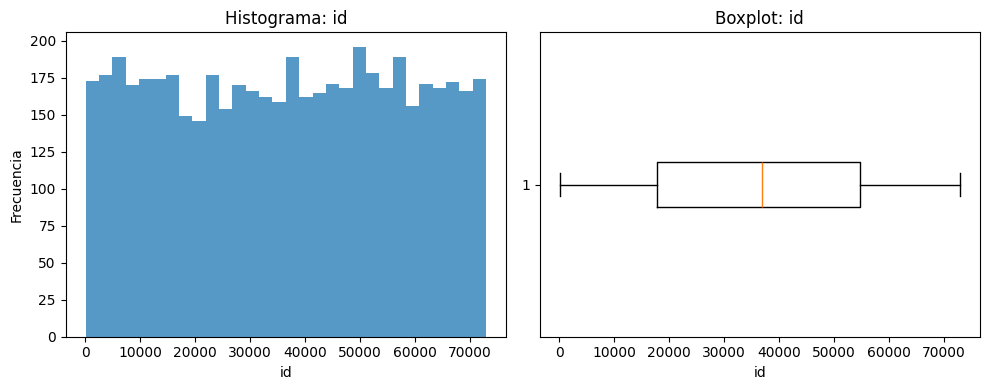

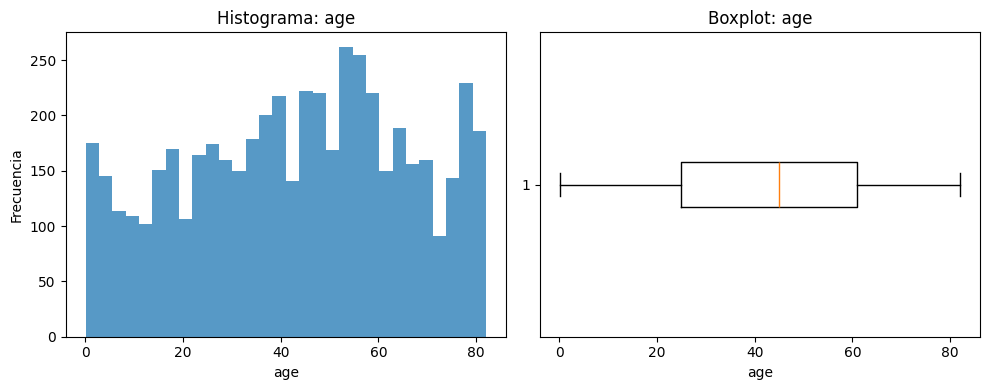

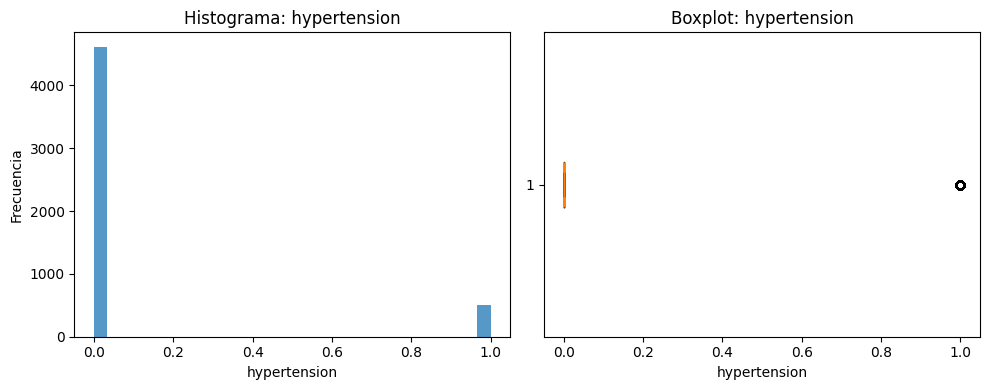

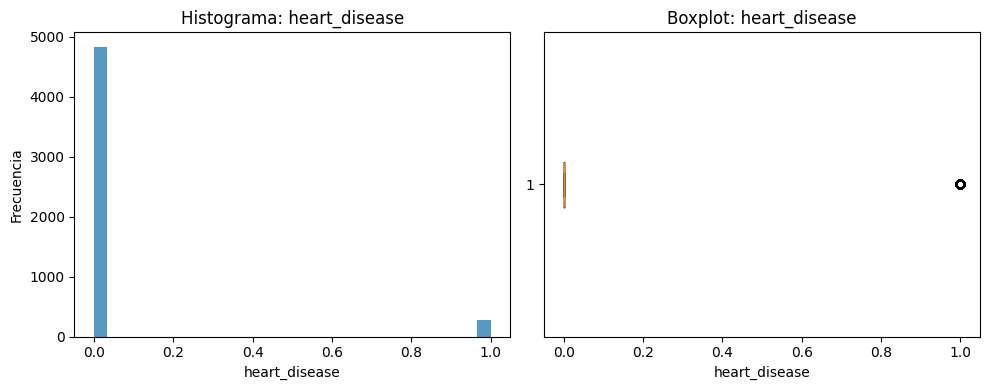

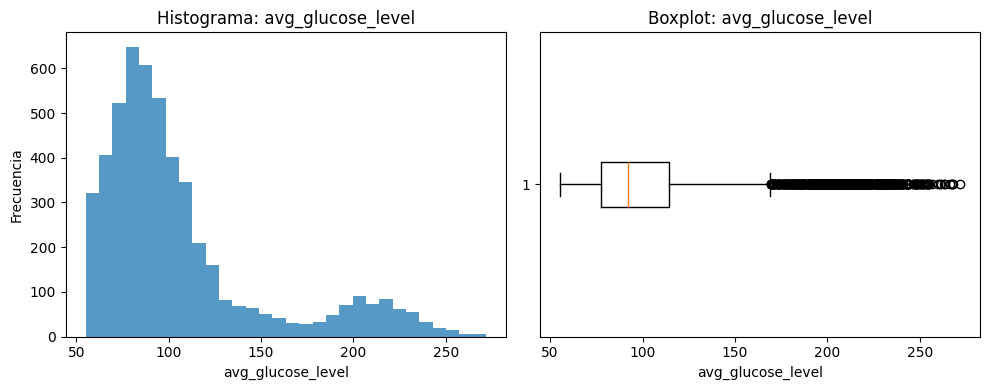

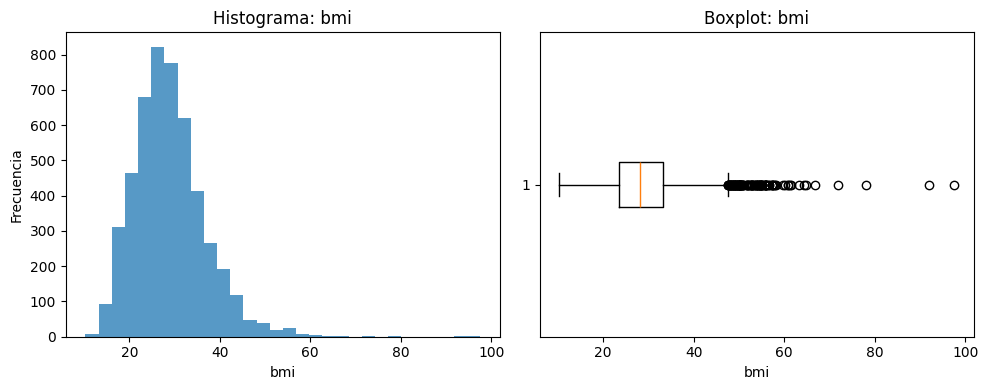

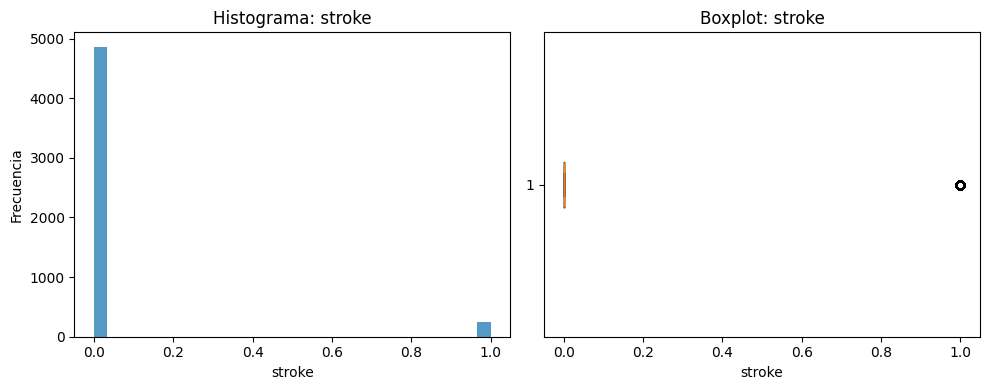

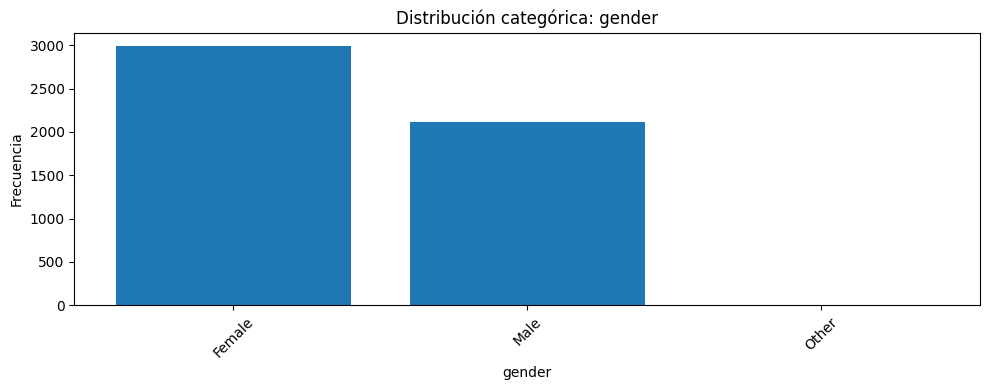

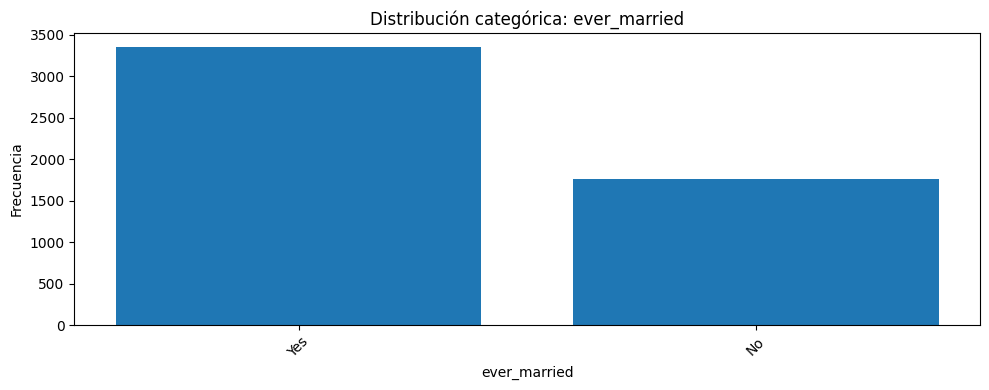

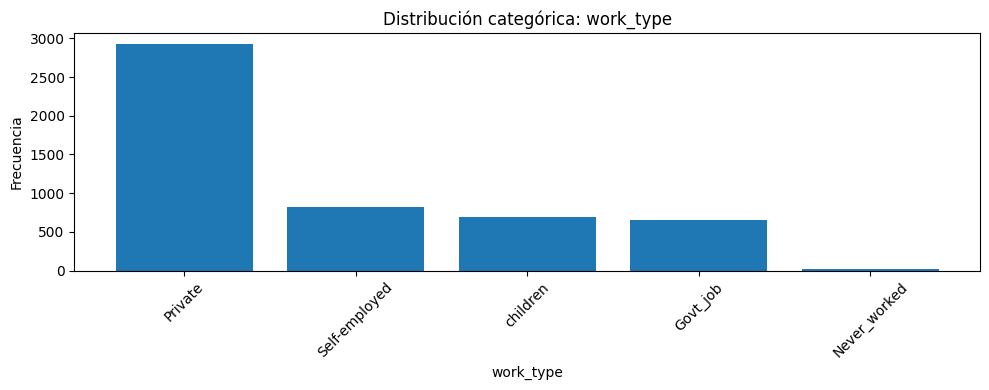

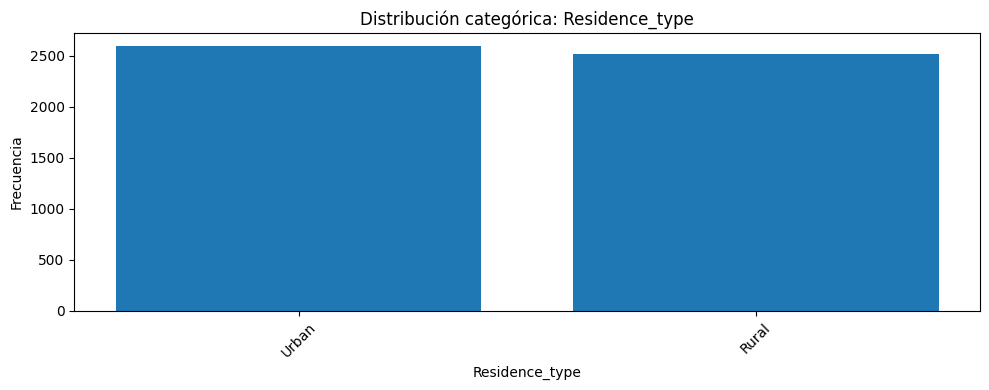

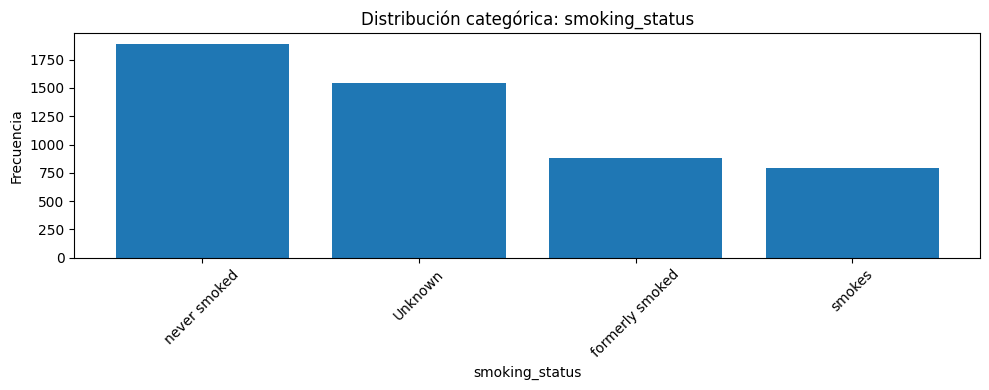

In [30]:
# Dimensiones del dataset
print("Dimensiones:", df.shape)

# Tipos de datos
print(df.dtypes)

# Valores faltantes
nulos_por_columna = df.isnull().sum()
porcentaje_nulos = (nulos_por_columna / len(df)) * 100

tabla_nulos = pd.DataFrame({
    'nulos': nulos_por_columna,
    'porcentaje_%': porcentaje_nulos.round(2)
}).sort_values(by='porcentaje_%', ascending=False)

print('Tabla de nulos por columna:')
display(tabla_nulos)

# Estadísticas descriptivas
display(df.describe().round(1))

# Distribución de variables numéricas
variables_numericas = df.select_dtypes(include=np.number).columns

for col in variables_numericas:
    plt.figure(figsize=(10, 4))

    # Histograma
    plt.subplot(1, 2, 1)
    plt.hist(df[col].dropna(), bins=30, alpha=0.75)
    plt.title(f'Histograma: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()



# Distribución de variables categóricas
variables_categoricas = df.select_dtypes(exclude=np.number).columns

for col in variables_categoricas:
    conteo = df[col].value_counts(dropna=False)

    plt.figure(figsize=(10, 4))
    plt.bar(conteo.index.astype(str), conteo.values)
    plt.title(f'Distribución categórica: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Limpieza mínima de datos — propósito

**Por qué se implementa:** en el análisis exploratorio aparecieron valores faltantes en `bmi` y colas pesadas en `bmi` y `avg_glucose_level` (desviaciones altas y extremos que distorsionan escalas y algoritmos como clustering).

**Para qué sirve:** preparar un `df_limpio` **sin eliminar filas**, de modo que los modelos y comparaciones posteriores (ruido, clustering) trabajen con magnitudes más estables y sin perder pacientes del conjunto.

**Qué hace este bloque en concreto:** quita el identificador `id` (no es señal clínica), imputa `bmi` con la **mediana** y aplica **winsorización al p5 y p95** en `bmi` y `avg_glucose_level` para acotar extremos sin borrar registros.

Tras ejecutar la celda de código, revisa la **tabla de métricas** y las **gráficas antes vs después** para validar que el efecto es el esperado.

Mediana usada para imputar bmi: 28.1
Cap bmi: [17.7000, 42.6550]
Cap avg_glucose_level: [60.7135, 216.2945]
Dimensiones df original: (5110, 12) | df_limpio: (5110, 11)
Variable: bmi


,Antes,Después
estadística,,
n_registros,5110.0,5110.0
nulos,201.0,0.0
min,10.0,18.0
p5,18.0,18.0
mediana,28.0,28.0
p95,43.0,43.0
max,98.0,43.0
media,29.0,29.0
std,8.0,7.0


Variable: avg_glucose_level


,Antes,Después
estadística,,
n_registros,5110.0,5110.0
nulos,0.0,0.0
min,55.0,61.0
p5,61.0,61.0
mediana,92.0,92.0
p95,216.0,216.0
max,272.0,216.0
media,106.0,106.0
std,45.0,43.0


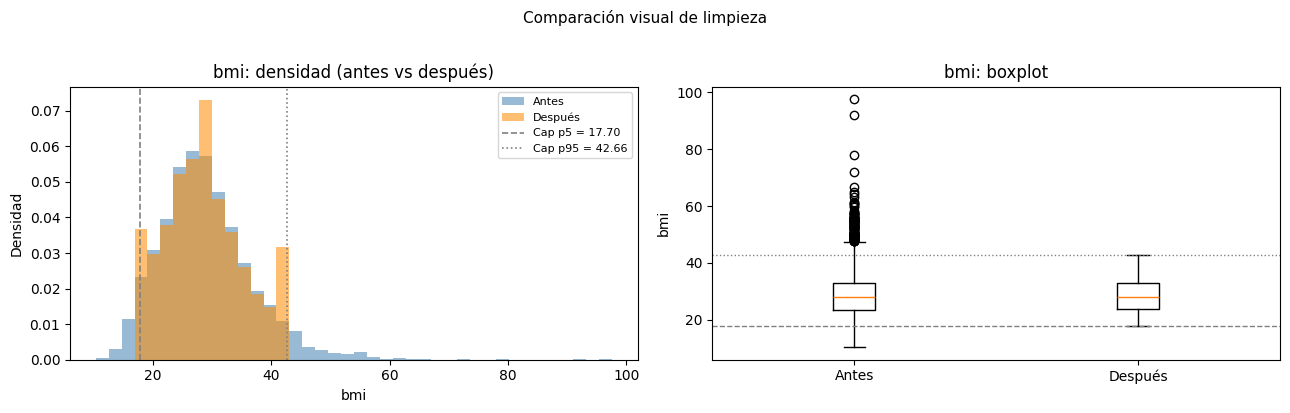

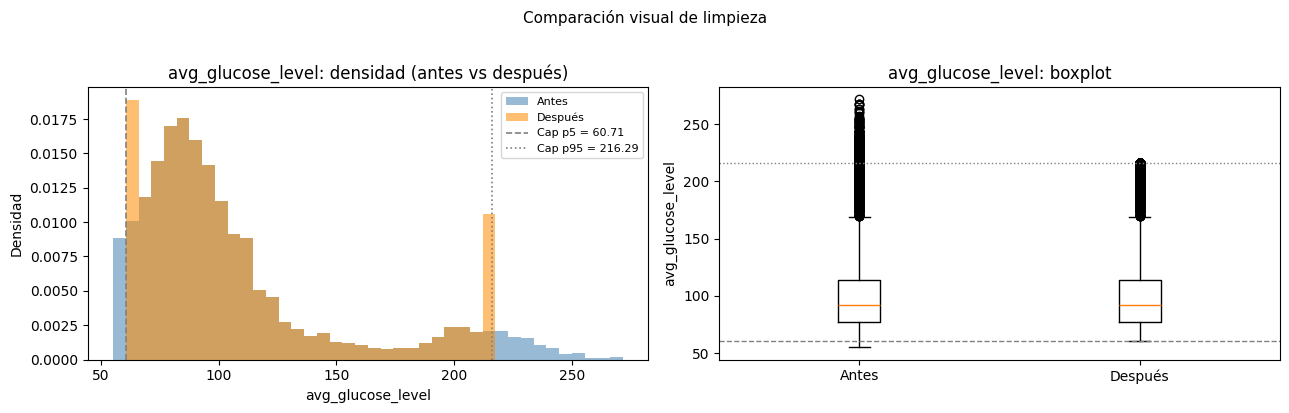

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,216.2945,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.2100,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.2300,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.1200,24.0,never smoked,1


In [31]:
# ============================================================
# Limpieza mínima del dataset (sin eliminar filas)
# ============================================================
# A partir de df original: quitar id, imputar bmi con mediana,
# cap de colas (winsorización) en bmi y avg_glucose_level al p5 y p95.

# --- Antes: métricas de referencia (bmi coercido a numérico para medir nulos reales) ---
bmi_antes = pd.to_numeric(df['bmi'], errors='coerce')
glucosa_antes = df['avg_glucose_level'].copy()

def metricas_serie(nombre, serie):
    s = serie.dropna()
    return pd.Series({
        'variable': nombre,
        'n_registros': len(serie),
        'nulos': serie.isna().sum(),
        'min': serie.min(),
        'p5': serie.quantile(0.05),
        'mediana': serie.median(),
        'p95': serie.quantile(0.95),
        'max': serie.max(),
        'media': serie.mean(),
        'std': serie.std(),
    })

tabla_antes = pd.DataFrame([
    metricas_serie('bmi', bmi_antes),
    metricas_serie('avg_glucose_level', glucosa_antes),
]).set_index('variable')

# --- Limpieza ---
df_limpio = df.copy()

# 1) Eliminar identificador (no aporta señal clínica)
df_limpio = df_limpio.drop(columns=['id'])

# 2) BMI: numérico + imputación por mediana (robusta)
df_limpio['bmi'] = pd.to_numeric(df_limpio['bmi'], errors='coerce')
mediana_bmi = df_limpio['bmi'].median()
df_limpio['bmi'] = df_limpio['bmi'].fillna(mediana_bmi)

# 3) Cap de atípicos (winsorización) en bmi y glucosa: percentiles 5 y 95
def winsorizar(serie, p_inferior=0.05, p_superior=0.95):
    low = serie.quantile(p_inferior)
    high = serie.quantile(p_superior)
    return serie.clip(lower=low, upper=high), low, high

df_limpio['bmi'], cap_bmi_low, cap_bmi_high = winsorizar(df_limpio['bmi'])
df_limpio['avg_glucose_level'], cap_glu_low, cap_glu_high = winsorizar(df_limpio['avg_glucose_level'])

print('Mediana usada para imputar bmi:', round(mediana_bmi, 4))
print(f'Cap bmi: [{cap_bmi_low:.4f}, {cap_bmi_high:.4f}]')
print(f'Cap avg_glucose_level: [{cap_glu_low:.4f}, {cap_glu_high:.4f}]')
print('Dimensiones df original:', df.shape, '| df_limpio:', df_limpio.shape)

# --- Después: mismas métricas ---
tabla_despues = pd.DataFrame([
    metricas_serie('bmi', df_limpio['bmi']),
    metricas_serie('avg_glucose_level', df_limpio['avg_glucose_level']),
]).set_index('variable')

# --- Comparación antes / después (una tabla por variable) ---
# Filas = cada estadística | Columnas = Antes vs Después
for nombre_variable in tabla_antes.index:
    comparacion_var = pd.DataFrame({
        'Antes': tabla_antes.loc[nombre_variable],
        'Después': tabla_despues.loc[nombre_variable],
    })
    comparacion_var.index.name = 'estadística'
    print(f'Variable: {nombre_variable}')
    display(comparacion_var.round(0))

# --- Gráficos: antes vs después (variables tocadas por la limpieza) ---
# bmi: imputación de nulos + winsorización | glucosa: solo winsorización

def graficar_antes_despues(nombre, serie_antes, serie_despues, cap_low, cap_high):
    """Histograma (mismos bins) + boxplot para comparar distribuciones."""
    a = serie_antes.dropna()
    d = serie_despues.dropna()
    vmin = float(min(a.min(), d.min()))
    vmax = float(max(a.max(), d.max()))
    if vmin == vmax:
        vmax = vmin + 1e-6
    bins = np.linspace(vmin, vmax, 41)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(a, bins=bins, alpha=0.55, label='Antes', color='steelblue', density=True)
    axes[0].hist(d, bins=bins, alpha=0.55, label='Después', color='darkorange', density=True)
    axes[0].axvline(cap_low, color='gray', linestyle='--', linewidth=1.2, label=f'Cap p5 = {cap_low:.2f}')
    axes[0].axvline(cap_high, color='gray', linestyle=':', linewidth=1.2, label=f'Cap p95 = {cap_high:.2f}')
    axes[0].set_title(f'{nombre}: densidad (antes vs después)')
    axes[0].set_xlabel(nombre)
    axes[0].set_ylabel('Densidad')
    axes[0].legend(loc='best', fontsize=8)

    axes[1].boxplot([a, d], vert=True)
    axes[1].set_xticklabels(['Antes', 'Después'])
    axes[1].axhline(cap_low, color='gray', linestyle='--', linewidth=1)
    axes[1].axhline(cap_high, color='gray', linestyle=':', linewidth=1)
    axes[1].set_title(f'{nombre}: boxplot')
    axes[1].set_ylabel(nombre)

    plt.suptitle('Comparación visual de limpieza', y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()


graficar_antes_despues('bmi', bmi_antes, df_limpio['bmi'], cap_bmi_low, cap_bmi_high)
graficar_antes_despues(
    'avg_glucose_level',
    glucosa_antes,
    df_limpio['avg_glucose_level'],
    cap_glu_low,
    cap_glu_high,
)

# Vista rápida del dataframe limpio
display(df_limpio.head())

# Opcional: usar el dataset limpio 
# df = df_limpio.copy()

### Interpretación de la limpieza (resultados obtenidos)

**Parámetros aplicados:** imputación de `bmi` con **mediana 28,1**; winsorización al **p5 y p95** con cortes **bmi** en **[17,70 ; 42,66]** y **glucosa** en **[60,71 ; 216,29]**. Se eliminó la columna `id`: el conjunto pasó de **(5110, 12)** a **(5110, 11)** filas, sin borrar pacientes.

**`bmi` (tabla y gráficas):** los **201 nulos (≈3,9 %)** pasaron a **0** al rellenar con la mediana. El **mínimo** subió de **10** a **18** y el **máximo** bajó de **98** a **43**, acorde al cap en torno a p5–p95; la **mediana se mantuvo en 28** y la **media en 29**, lo que indica que el centro de la distribución casi no se movió. La **desviación típica** bajó de **8** a **7**: menos dispersión por colas extremas. En el histograma “Después” aparecen **picos en los límites del cap** (valores recortados que se acumulan en el min y max); en el boxplot desaparecen los **outliers** por encima del max, alineados con las líneas de referencia del cap.

**`avg_glucose_level`:** no había nulos; el cambio es casi solo por **capping**. El **mínimo** pasó de **55** a **61** y el **máximo** de **272** a **216**; **mediana (92)** y **media (106)** se mantienen, y **`std` baja de 45 a 43**. Las gráficas muestran colas recortadas y acumulación en **60,71** y **216,29**, típico de winsorización sin eliminar filas.

**Conclusión:** la limpieza **recorta valores extremos** y **completa `bmi`** sin alterar el centro (medianas iguales), preparando mejor para escalado y clustering. 


# 🔐 Identificación de variables sensibles

En datos de salud, una variable es **sensible** si revela información personal o clínica que podría usarse para discriminar, estigmatizar o **reidentificar** a una persona (especialmente al cruzar varias columnas).

### Variables consideradas en este trabajo

- **`id`:** es **identificador directo**; la protección adecuada es **no publicarlo ni usarlo en modelado** (no sumarle ruido al código). En `df_limpio` la columna `id` **ya fue eliminada** en la limpieza.
- **`age` (edad):** **cuasi-identificador** muy fuerte; combinada con sexo, trabajo o tabaquismo reduce mucho el anonimato. Es **numérica** → encaja con el **mecanismo Gaussiano** de OpenDP (SmartNoise) en la Parte 3.
- **`bmi` (índice de masa corporal):** dato **antropométrico / clínico** sensible; puede relacionarse con estigma o inferencias de salud. Tras la limpieza está **sin nulos**, en rango acotado por winsorización, y sigue siendo **numérica** → también admite ruido aditivo.
- **`smoking_status`:** es **sensible** pero **categórica**; el esquema actual del notebook aplica ruido columna a columna sobre **números**. 




In [32]:
# Variables sensibles: se trabaja sobre df_limpio (sin id; bmi ya imputado y acotado).

variables_sensibles = ['age', 'bmi']

print('Base de trabajo:', 'df_limpio')
print('Columnas con mecanismo Gaussiano OpenDP (SmartNoise):', variables_sensibles)


Base de trabajo: df_limpio
Columnas con mecanismo Gaussiano OpenDP (SmartNoise): ['age', 'bmi']


# 🔐 Parte 3 — Aplicar privacidad diferencial (SmartNoise / OpenDP)

Siguiendo la guía (`pip install opendp-smartnoise`), se usa el **mecanismo Gaussiano** de **OpenDP** (`dp.m.then_gaussian`), componente estándar del stack **SmartNoise/OpenDP**, para perturbar las variables sensibles numéricas (**`age`** y **`bmi`**) sobre una copia de `df_limpio`. 


In [33]:
# Copia del dataset limpio; se prueban varios sigma y al final se fija df_privado.

SIGMAS_A_PROBAR = [0.25, 0.5, 1.0, 2.0]
sigma_elegido = 1 # el que usarán histogramas, clustering, etc.
RNG_SEED = 42


def aplicar_ruido_gaussiano(df_base, sigma_val, semilla=None):
    """Perturba columnas en `variables_sensibles` con el mecanismo Gaussiano de OpenDP.

    OpenDP es el núcleo actual del ecosistema SmartNoise; `scale` coincide con la desviación
    típica del ruido Gaussiano. El parámetro `semilla` se conserva por compatibilidad con el
    resto del notebook pero OpenDP no expone semilla por valor; las salidas pueden variar
    entre ejecuciones (comportamiento habitual en DP).
    """
    dp.enable_features('contrib', 'floating-point')
    out = df_base.copy()
    input_space = (
        dp.atom_domain(T=float, nan=False),
        dp.absolute_distance(T=float),
    )
    meas = input_space >> dp.m.then_gaussian(scale=float(sigma_val))
    for col in variables_sensibles:
        colvals = out[col].to_numpy(dtype=float, copy=False)
        nuevo = np.empty_like(colvals, dtype=float)
        for i in range(len(colvals)):
            v = colvals[i]
            nuevo[i] = np.nan if np.isnan(v) else float(meas(float(v)))
        out[col] = nuevo
    return out


# Tabla resumen: RMSE entre limpio y perturbado (solo columnas sensibles)
filas_resumen = []
for i, s in enumerate(SIGMAS_A_PROBAR):
    df_tmp = aplicar_ruido_gaussiano(df_limpio, s, semilla=RNG_SEED + i)
    for col in variables_sensibles:
        diff = df_tmp[col].to_numpy() - df_limpio[col].to_numpy()
        filas_resumen.append({
            'sigma': s,
            'columna': col,
            'rmse': float(np.sqrt(np.mean(diff ** 2))),
        })

tabla_sigma = pd.DataFrame(filas_resumen)
print('RMSE (limpio vs perturbado) por sigma y columna:')
display(tabla_sigma.pivot(index='sigma', columns='columna', values='rmse').round(4))

# Versión definitiva para el resto del notebook
sigma = sigma_elegido
df_privado = aplicar_ruido_gaussiano(df_limpio, sigma, semilla=RNG_SEED + 100)
print(f"\n df_privado fijado con sigma = {sigma} (cambia sigma_elegido o SIGMAS_A_PROBAR arriba).")

df_privado.head()


RMSE (limpio vs perturbado) por sigma y columna:


columna,age,bmi
sigma,,
0.25,0.2497,0.2486
0.50,0.4989,0.4988
1.00,1.0071,0.9961
2.00,2.0018,1.9984



 df_privado fijado con sigma = 1 (cambia sigma_elegido o SIGMAS_A_PROBAR arriba).


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,66.854937,0,1,Yes,Private,Urban,216.2945,37.751634,formerly smoked,1
1,Female,59.740643,0,0,Yes,Self-employed,Rural,202.2100,27.507970,never smoked,1
2,Male,80.526149,0,1,Yes,Private,Rural,105.9200,32.217529,never smoked,1
3,Female,50.554050,0,0,Yes,Private,Urban,171.2300,33.292851,smokes,1
4,Female,79.350018,1,0,Yes,Self-employed,Rural,174.1200,24.171798,never smoked,1


# 📊 Comparación de variables originales vs privadas

En esta sección se compara `df_limpio` frente a versiones perturbadas con **OpenDP / SmartNoise** (`then_gaussian`): para **cada variable sensible** se recorre **cada valor de `SIGMAS_A_PROBAR`**, con **histograma** (mismos bins) y **boxplot** en una fila por sigma. Así se puede ver cómo crece la dispersión al subir σ.


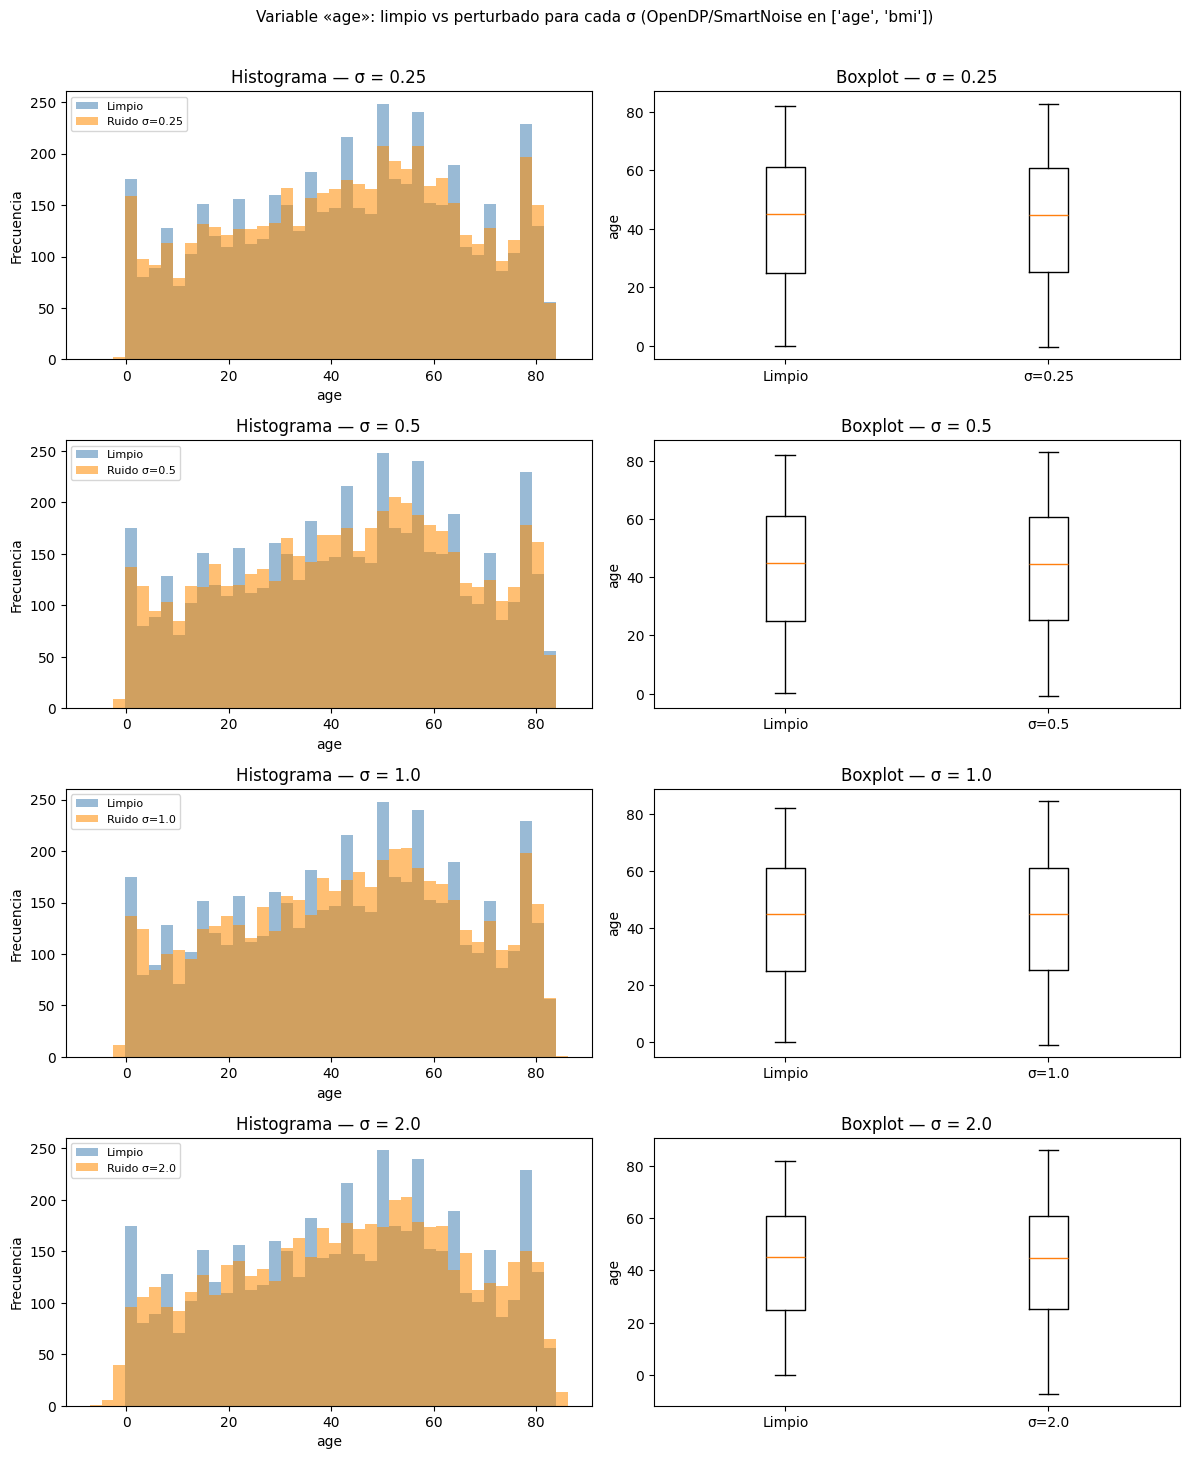

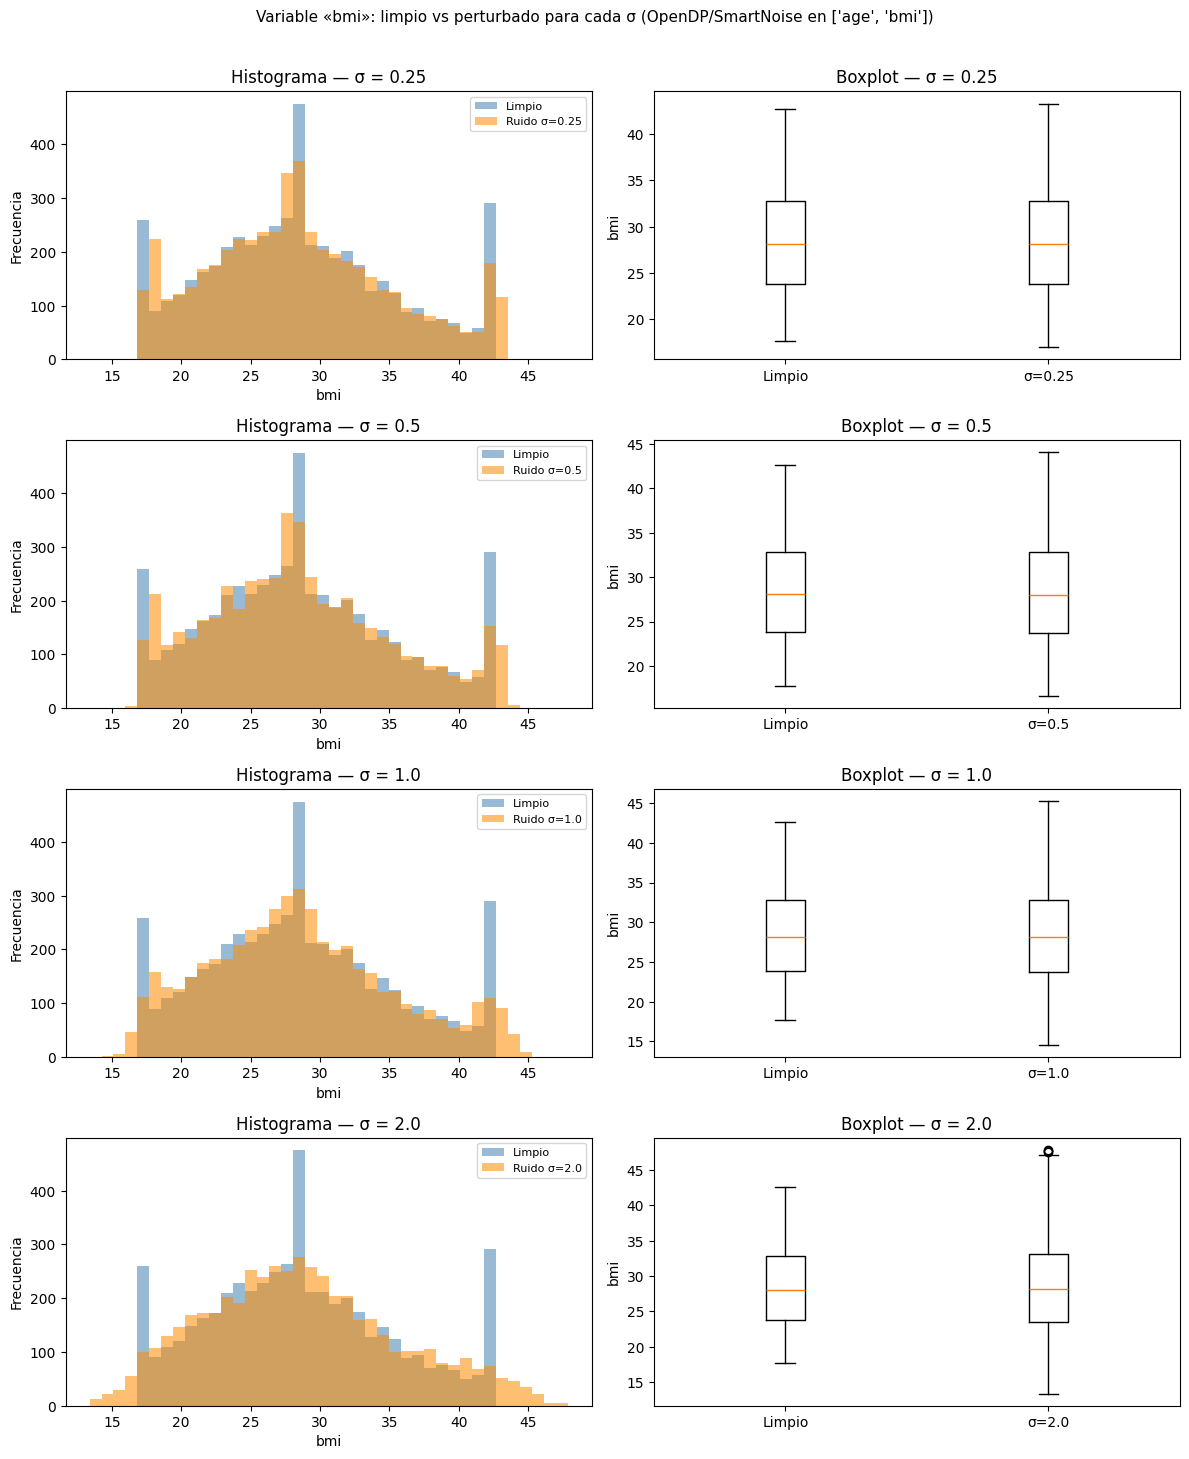

Figuras anteriores: barrido de sigma. df_privado sigue usando sigma_elegido = 1.


In [34]:
# Comparación visual por variable y por sigma (histograma + boxplot)
# Reutiliza SIGMAS_A_PROBAR y aplicar_ruido_gaussiano de la celda de ruido (si no existen, se definen aquí).

if 'SIGMAS_A_PROBAR' not in dir():
    SIGMAS_A_PROBAR = [0.25, 0.5, 1.0, 2.0]
if 'RNG_SEED' not in dir():
    RNG_SEED = 42
if 'aplicar_ruido_gaussiano' not in dir():

    def aplicar_ruido_gaussiano(df_base, sigma_val, semilla=None):
        import opendp.prelude as dp
        dp.enable_features('contrib', 'floating-point')
        out = df_base.copy()
        input_space = (
            dp.atom_domain(T=float, nan=False),
            dp.absolute_distance(T=float),
        )
        meas = input_space >> dp.m.then_gaussian(scale=float(sigma_val))
        for col in variables_sensibles:
            colvals = out[col].to_numpy(dtype=float, copy=False)
            nuevo = np.empty_like(colvals, dtype=float)
            for i in range(len(colvals)):
                v = colvals[i]
                nuevo[i] = np.nan if np.isnan(v) else float(meas(float(v)))
            out[col] = nuevo
        return out


for col in variables_sensibles:
    n_sig = len(SIGMAS_A_PROBAR)
    a = df_limpio[col].dropna()

    # Generar todas las versiones con ruido (una por sigma)
    dfs_con_ruido = [
        aplicar_ruido_gaussiano(df_limpio, s, semilla=RNG_SEED + i)
        for i, s in enumerate(SIGMAS_A_PROBAR)
    ]

    # Bins fijos para TODAS las filas: unión del rango limpio + todas las perturbadas.
    lo, hi = float(a.min()), float(a.max())
    for df_tmp in dfs_con_ruido:
        b = df_tmp[col].dropna()
        lo = min(lo, float(b.min()))
        hi = max(hi, float(b.max()))
    if lo == hi:
        hi = lo + 1e-9
    bins = np.linspace(lo, hi, 41)

    if n_sig == 1:
        fig, axes_row = plt.subplots(1, 2, figsize=(12, 4))
        filas_axes = [axes_row]
    else:
        fig, axes_grid = plt.subplots(n_sig, 2, figsize=(12, 3.6 * n_sig))
        filas_axes = [axes_grid[i, :] for i in range(n_sig)]

    for i, sigma_val in enumerate(SIGMAS_A_PROBAR):
        df_tmp = dfs_con_ruido[i]
        b = df_tmp[col].dropna()

        ax0, ax1 = filas_axes[i][0], filas_axes[i][1]

        ax0.hist(a, bins=bins, alpha=0.55, label='Limpio', color='steelblue')
        ax0.hist(b, bins=bins, alpha=0.55, label=f'Ruido σ={sigma_val}', color='darkorange')
        ax0.set_ylabel('Frecuencia')
        ax0.legend(loc='best', fontsize=8)
        ax0.set_title(f'Histograma — σ = {sigma_val}')
        ax0.set_xlabel(col)

        ax1.boxplot([a, b], vert=True)
        ax1.set_xticklabels(['Limpio', f'σ={sigma_val}'])
        ax1.set_ylabel(col)
        ax1.set_title(f'Boxplot — σ = {sigma_val}')

    plt.suptitle(
        f'Variable «{col}»: limpio vs perturbado para cada σ (OpenDP/SmartNoise en {variables_sensibles})',
        y=1.01,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

# Una fila adicional: comparación con df_privado (sigma_elegido) si existe
if 'df_privado' in dir() and 'sigma_elegido' in dir():
    print(f'Figuras anteriores: barrido de sigma. df_privado sigue usando sigma_elegido = {sigma_elegido}.')


### Interpretación — comparación visual limpio vs perturbado (por `sigma`)

**Qué muestran los histogramas (mismos bins en todas las filas):** la curva **azul** es siempre `df_limpio`; la **naranja** es la misma columna tras aplicar el **mecanismo Gaussiano de OpenDP** (`then_gaussian`, stack SmartNoise/OpenDP) con el `σ` (`scale`) de esa fila a **todas** las columnas listadas en `variables_sensibles` (`age` y `bmi`). Al subir `σ`, la distribución naranja se **ensancha** y **suaviza** picos del azul: se pierde detalle fino (más privacidad visual) pero se mantiene en gran medida la forma global.

**`age`:** con `σ` pequeño, azul y naranja casi coinciden. Con `σ` grande, el naranja **difumina** los picos de edad y puede aparecer masa fuera del rango original (valores negativos o por encima del máximo observado), típico del ruido aditivo sin recorte posterior. Los **boxplots** suelen seguir parecidos en mediana e IQR mientras el ruido sea moderado; los bigotes más largos u outliers en el naranja, es la dispersión extra del ruido.

**`bmi`:** el azul refleja la forma ya “marcada” por la limpieza (picos en imputación/cap). El naranja **aplana** esos picos al aumentar `σ`: se enmascara mejor **quién** tenía exactamente esos valores. Con `σ` alto pueden salir **outliers** nuevos en el boxplot (valores extremos por el ruido), aunque el centro del recuadro cambie poco.

**Para elegir `sigma_elegido`:** Se busca el **mayor `σ`** en el que aún parezca aceptable la utilidad (forma razonable del naranja, boxplots no “explosionados”) antes de pasar a clustering. 


# 🧠 Parte 4 — Clustering

**Qué se hace:** se elige la **Opción A — K-Means** sobre las **columnas numéricas** de `df_limpio` y, con el **mismo número de clusters** y la **misma semilla**, sobre `df_privado` (ruido DP en `age` y `bmi` según la Parte 3).

**Pasos en el notebook:** (1) **Elegir `k`** solo con `df_limpio` (inercia + silhouette en la siguiente subsección). (2) **Entrenar** K-Means en limpio y en privado con ese **`N_CLUSTERS`**.

**Por qué:** se ejecuta clustering sobre el **dataset original (limpio)** y el **dataset protegido** para comparar el impacto del ruido en el aprendizaje no supervisado.



### Elección de **k** (solo `df_limpio`)

Se recorre **k** en un rango sobre **datos limpios escalados**: curva de **inercia** (codo) y **silhouette** medio. La tabla y los gráficos sirven para fijar **`N_CLUSTERS`** (puedes **sobrescribir** el valor sugerido si el codo y el silhouette no coinciden).


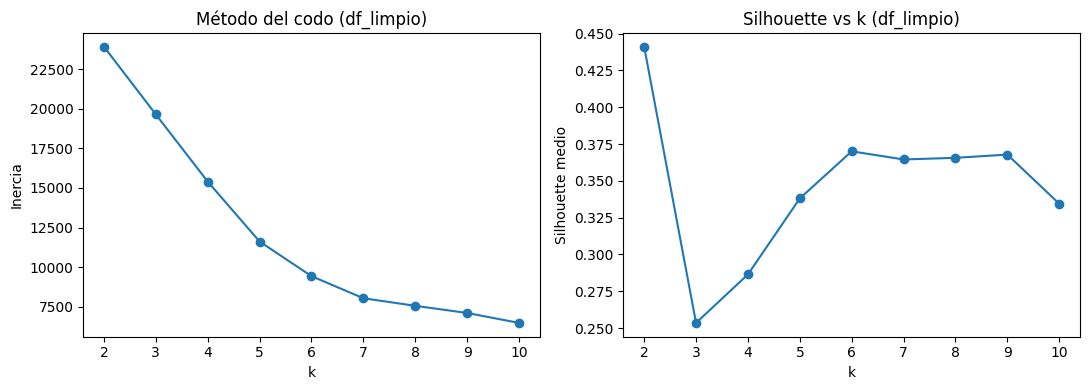

,k,inercia,silhouette
0,2,23931.0728,0.4411
1,3,19650.5975,0.2535
2,4,15406.8996,0.2865
3,5,11617.2451,0.3381
4,6,9429.7002,0.3701
5,7,8034.3743,0.3645
6,8,7554.7613,0.3656
7,9,7102.5156,0.3678
8,10,6474.6676,0.3345


k con mayor silhouette en [2, 10]: 2
N_CLUSTERS que se usará en K-Means (limpio y privado): 6


In [46]:
# Solo df_limpio: mismas columnas numéricas que usará el clustering.
X_original = df_limpio.select_dtypes(include=np.number)
scaler = StandardScaler()
X_original_scaled = scaler.fit_transform(X_original)

K_MIN, K_MAX = 2, 10
k_rango = range(K_MIN, K_MAX + 1)
inercias = []
silhouettes = []
for k in k_rango:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    etiquetas = km.fit_predict(X_original_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_original_scaled, etiquetas))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_rango), inercias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo (df_limpio)")

axes[1].plot(list(k_rango), silhouettes, marker="o")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette medio")
axes[1].set_title("Silhouette vs k (df_limpio)")
plt.tight_layout()
plt.show()

tabla_k = pd.DataFrame({"k": list(k_rango), "inercia": inercias, "silhouette": silhouettes})
display(tabla_k.round(4))

k_sugerido = int(tabla_k.loc[tabla_k["silhouette"].idxmax(), "k"])
print("k con mayor silhouette en [{}, {}]: {}".format(K_MIN, K_MAX, k_sugerido))

# Tras revisar codo + tabla: deja k_sugerido o escribe tu k a mano.
#N_CLUSTERS = k_sugerido
N_CLUSTERS = 6  # ejemplo: descomenta y fija k si no quieres usar el máximo silhouette

print("N_CLUSTERS que se usará en K-Means (limpio y privado):", N_CLUSTERS)



In [47]:
# Celda anterior: elige k con inercia/silhouette y define X_original, scaler, X_original_scaled, N_CLUSTERS.
X_privado = df_privado.select_dtypes(include=np.number)
X_privado = X_privado[X_original.columns]  # mismo orden de columnas
X_privado_scaled = scaler.transform(X_privado)

# K-Means (Opción A): mismo k y misma semilla en limpio y privado.
kmeans_original = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
clusters_original = kmeans_original.fit_predict(X_original_scaled)

kmeans_privado = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
clusters_privado = kmeans_privado.fit_predict(X_privado_scaled)

print("Columnas en clustering:", list(X_original.columns))
print("k (número de clusters):", N_CLUSTERS)


Columnas en clustering: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
k (número de clusters): 6


# 📊 Parte 5 — Comparación 

**Qué se hace:** se contrasta el clustering **limpio vs protegido** con lo que pide la guía: **número de clusters**, **silhouette score**, lectura de **separación** (en la Parte 6 con gráficos), **impacto del ruido** y una lectura simple de **estabilidad** (misma semilla y mismo `k`; se mide cuánto cambian las asignaciones frente a las filas).

**Qué observar:** si el silhouette cae mucho en el privado, el ruido debilitó la estructura de grupos; el **NMI** (información mutua normalizada) resume cuánto coinciden las agrupaciones de los mismos pacientes entre ambas versiones (sin exigir que el «color» del cluster sea el mismo número).


In [48]:
score_original = silhouette_score(X_original_scaled, clusters_original)
score_privado = silhouette_score(X_privado_scaled, clusters_privado)
nmi = normalized_mutual_info_score(clusters_original, clusters_privado)

print("Número de clusters (k) en ambos modelos:", N_CLUSTERS)
if "sigma_elegido" in dir():
    print("sigma_elegido usado en df_privado:", sigma_elegido)
print()
print("Silhouette — original:", round(score_original, 4))
print("Silhouette — privado:", round(score_privado, 4))
print("Diferencia (privado − original):", round(score_privado - score_original, 4))
print("NMI entre particiones (mismo orden de filas):", round(nmi, 4))
print()
print("Pacientes por cluster (limpio):")
print(pd.Series(clusters_original).value_counts().sort_index())
print("Pacientes por cluster (privado):")
print(pd.Series(clusters_privado).value_counts().sort_index())


Número de clusters (k) en ambos modelos: 6
sigma_elegido usado en df_privado: 1

Silhouette — original: 0.3701
Silhouette — privado: 0.3258
Diferencia (privado − original): -0.0442
NMI entre particiones (mismo orden de filas): 0.8206

Pacientes por cluster (limpio):
0    2197
1     440
2     249
3     229
4     381
5    1614
Name: count, dtype: int64
Pacientes por cluster (privado):
0    1683
1     150
2     249
3     701
4      79
5    2248
Name: count, dtype: int64


### Descripción de la comparación (resultados con **k = 6**, **σ = 1**)

**Silhouette:** en el conjunto **limpio** el valor es **0,3701** y en el **privado** **0,3258** (baja **≈ 0,044**). Eso indica que, tras el ruido gaussiano en `age` y `bmi`, los grupos quedan algo **menos cohesionados/separados en promedio** en el espacio escalado, lo cual es coherente con una ligera **deformación** de la geometría que usa K-Means. La caída es **moderada**, no sugiere que el ruido haya borrado por completo la estructura de clusters.

**NMI (≈ 0,82):** mide cuánto se parecen las **dos particiones** sobre las **mismas filas** (mismos pacientes en el mismo orden), sin importar cómo se numeren los clusters. Un valor **alto** implica que, a nivel global, **muchas decisiones de agrupación** se mantienen alineadas entre limpio y privado, aunque los **tamaños** de cluster cambien.

**Conteos por cluster:** la distribución de pacientes **sí cambia** entre versiones (p. ej. el cluster **5** pasa de **1614** a **2248**, el **0** de **2197** a **1683**, el **3** de **229** a **701**, el **4** de **381** a **79**). Eso refleja que muchos puntos **cruzan fronteras** entre centroides al moverse `age` y `bmi`. El cluster **4** en el privado queda **muy pequeño (79)**: conviene interpretarlo con cautela (grupo poco numeroso, sensible al ruido o a la posición de centroides). El hecho de que el cluster **2** tenga **249** pacientes en ambos casos puede ser **coincidencia** de tamaño; no implica por sí solo que sean exactamente los mismos individuos.

**Lectura conjunta para el informe:** con **σ = 1** y **k = 6**, se observa un **trade-off típico**: algo de **pérdida de calidad métrica** (silhouette) y **redistribución** de masas entre clusters, pero una **alta similitud** entre particiones (NMI), coherente con proteger dos variables numéricas sensibles sin destruir del todo el agrupamiento obtenido en limpio.

# 📈 Parte 6 — Visualización

**Qué se hace:** gráficas **antes (limpio) / después (privado)** de los clusters en el plano **edad–IMC** (las dos variables donde se aplicó ruido en la Parte 3), usando coordenadas **estandarizadas** como en el modelo. Se añaden **leyenda por cluster**, **centroides** proyectados en ese plano (marca X) y un fondo suave para leer mejor la densidad.

**Qué observar:** si los grupos se ven más mezclados en el panel privado, el ruido está alterando la geometría que K-Means usa para separar pacientes. K-Means usa **todas** las columnas numéricas: en 2D siempre habrá **solape** aunque los clusters existan en dimensión mayor.


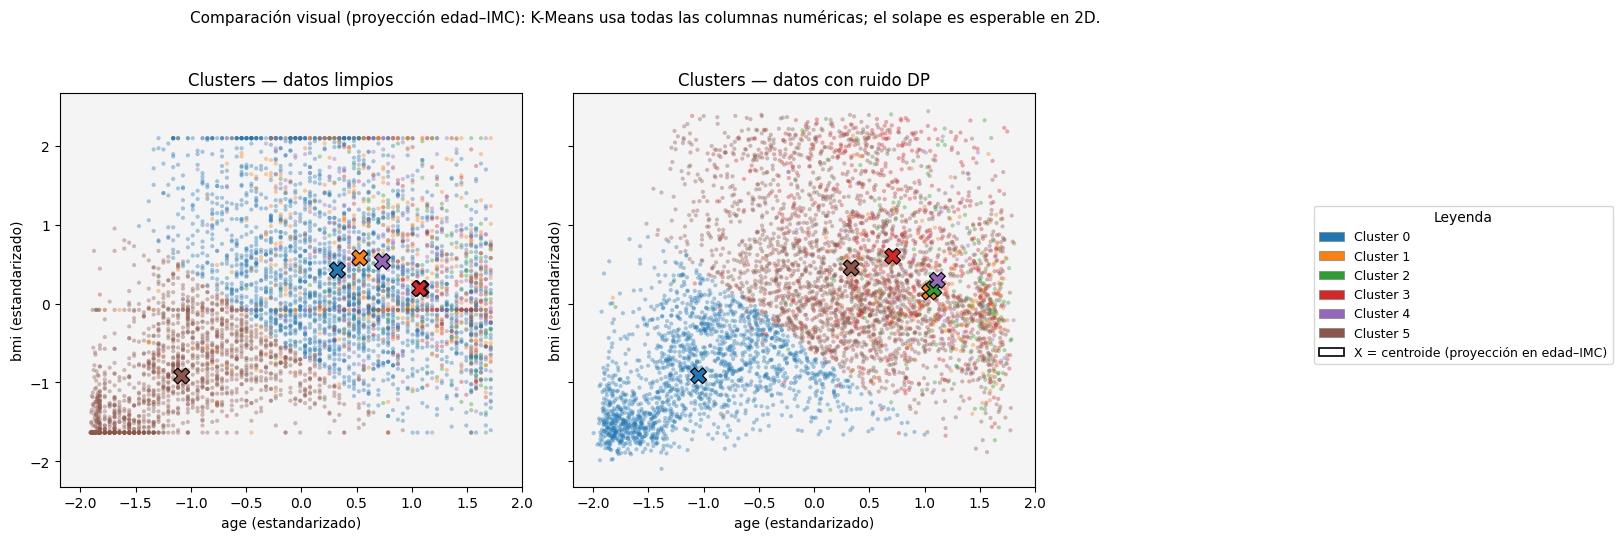

In [52]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

cols = list(X_original.columns)
i_age, i_bmi = cols.index("age"), cols.index("bmi")

x_orig = X_original_scaled[:, i_age]
y_orig = X_original_scaled[:, i_bmi]
x_priv = X_privado_scaled[:, i_age]
y_priv = X_privado_scaled[:, i_bmi]

# Colores fijos (primeros k colores de tab10) para leyenda y centroides alineados.
colores_k = plt.cm.tab10.colors[:N_CLUSTERS]
cmap_k = ListedColormap(colores_k)

centroids_o = kmeans_original.cluster_centers_[:, [i_age, i_bmi]]
centroids_p = kmeans_privado.cluster_centers_[:, [i_age, i_bmi]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)


def plot_panel(ax, x, y, etiquetas, titulo, centroids):
    ax.set_facecolor("#f4f4f4")
    ax.scatter(
        x,
        y,
        c=etiquetas,
        cmap=cmap_k,
        vmin=0,
        vmax=N_CLUSTERS - 1,
        alpha=0.38,
        s=9,
        linewidths=0,
        rasterized=True,
    )
    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        c=list(range(N_CLUSTERS)),
        cmap=cmap_k,
        vmin=0,
        vmax=N_CLUSTERS - 1,
        marker="X",
        s=130,
        edgecolors="black",
        linewidths=0.85,
        zorder=6,
    )
    ax.set_xlabel("age (estandarizado)")
    ax.set_ylabel("bmi (estandarizado)")
    ax.set_title(titulo)


plot_panel(axes[0], x_orig, y_orig, clusters_original, "Clusters — datos limpios", centroids_o)
plot_panel(axes[1], x_priv, y_priv, clusters_privado, "Clusters — datos con ruido DP", centroids_p)

leyenda_patches = [
    mpatches.Patch(facecolor=colores_k[k], edgecolor="gray", linewidth=0.5, label=f"Cluster {k}")
    for k in range(N_CLUSTERS)
]
leyenda_patches.append(
    mpatches.Patch(
        facecolor="none",
        edgecolor="black",
        linewidth=1.2,
        label="X = centroide (proyección en edad–IMC)",
    )
)
fig.legend(
    handles=leyenda_patches,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=9,
    frameon=True,
    title="Leyenda",
)

plt.suptitle(
    "Comparación visual (proyección edad–IMC): K-Means usa todas las columnas numéricas; el solape es esperable en 2D.",
    y=1.03,
    fontsize=11,
)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


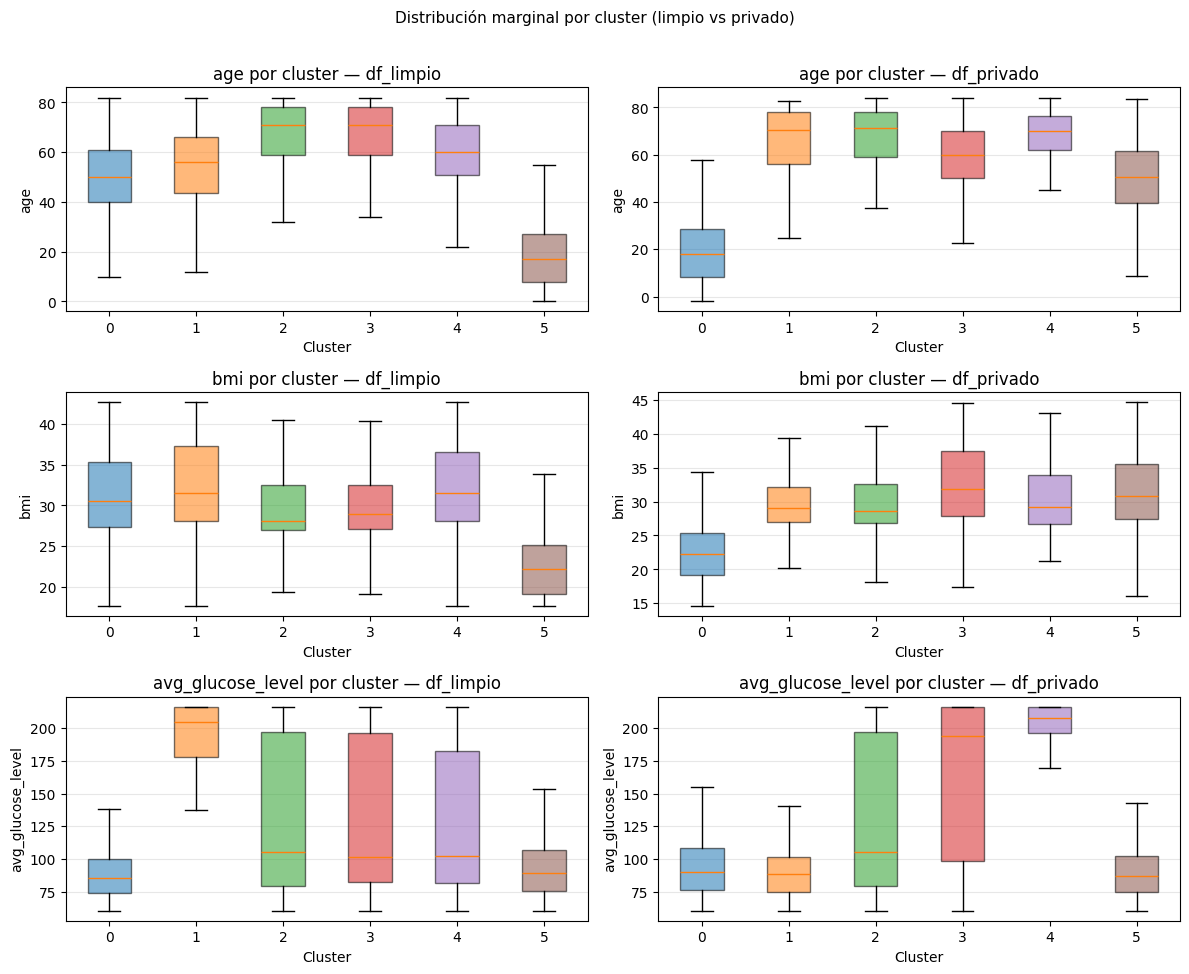

In [53]:
vars_marginales = ["age", "bmi", "avg_glucose_level"]

fig, axes = plt.subplots(len(vars_marginales), 2, figsize=(12, 3.2 * len(vars_marginales)), sharey=False)
if len(vars_marginales) == 1:
    axes = np.array([axes])

for row, var in enumerate(vars_marginales):
    for col, (df_plot, etiquetas, titulo_df) in enumerate(
        [
            (df_limpio, clusters_original, "df_limpio"),
            (df_privado, clusters_privado, "df_privado"),
        ]
    ):
        ax = axes[row, col]
        datos_por_k = [df_plot.loc[etiquetas == k, var].dropna().to_numpy() for k in range(N_CLUSTERS)]
        bp = ax.boxplot(
            datos_por_k,
            tick_labels=[str(k) for k in range(N_CLUSTERS)],
            patch_artist=True,
            showfliers=False,
        )
        for patch, k in zip(bp["boxes"], range(N_CLUSTERS)):
            patch.set_facecolor(plt.cm.tab10.colors[k % 10])
            patch.set_alpha(0.55)
        ax.set_xlabel("Cluster")
        ax.set_ylabel(var)
        ax.set_title(f"{var} por cluster — {titulo_df}")
        ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Distribución marginal por cluster (limpio vs privado)", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()


### Interpretación — gráficos de la Parte 6

**Scatter edad–IMC (estandarizado):** es una **proyección 2D** del mismo K-Means que entrena en **todas** las columnas numéricas; por eso los colores se **mezclan** en el plano aunque los clusters existan en dimensión mayor. Las **X** marcan los **centroides** proyectados: al añadir ruido DP en `age` y `bmi`, los centroides se **desplazan** y muchos puntos **cambian de etiqueta**. Es normal que el **número de cluster** (0…5) **no coincida** entre limpio y privado para el **mismo perfil** (p. ej. el grupo joven / IMC bajo puede pasar del color «cluster 5» al «cluster 0»): K-Means no fija un significado clínico a cada índice, solo particiona la nube.

**Boxplots por variable:** leen la distribución **marginal** de cada variable **dentro de cada etiqueta** de cluster.

- **`age` y `bmi`:** en `df_privado` esas columnas **sí** llevan el mecanismo gaussiano; además, al cambiar las asignaciones, los boxplots por cluster combinan **dos efectos**: valores perturbados y **nueva composición** de cada grupo.
- **`avg_glucose_level`:** en este taller **no** se aplica ruido DP a la glucosa; **fila a fila** debería ser **igual** que en `df_limpio`. **Si** los boxplots de glucosa **cambian de forma** entre columnas, la causa principal es la **reasignación de clusters** (mismas glucosas, distinto «cajón»), no que el DP haya alterado directamente la glucosa.



# 🧠 Parte 7 — Interpretación 

 **K-Means con `k = 6`**, **`sigma_elegido = 1`** en `df_privado`, ruido gaussiano solo en **`age`** y **`bmi`**, y **misma semilla** en limpio y privado.

1. **¿El ruido destruyó completamente los patrones?**  
   **No.** El **silhouette** baja de **0,3701** (limpio) a **0,3258** (privado), es decir **≈ −0,044**: hay algo menos de separación/cohesión media en el espacio escalado, pero no un colapso. El **NMI** entre particiones es **≈ 0,82**, alto: a nivel global muchos pacientes siguen “cerca” de la misma agrupación relativa aunque cambien etiquetas y tamaños de cluster. En la Parte 6 se ve solape en el plano edad–IMC (esperable: K-Means usa **todas** las numéricas) y, aun así, se distinguen perfiles que se **desplazan** con el DP.

2. **¿Qué tanto cambió el clustering?**  
   **Moderadamente** en métrica global y **mucho** en etiquetas y tamaños: el silhouette cae poco, pero los **conteos por cluster** se **redistribuyen** (p. ej. más masa en un cluster y otro muy pequeño en privado). Los **números de cluster 0…5 no son comparables** entre columnas del gráfico (permutación de etiquetas): un mismo perfil puede ser “cluster 5” en limpio y “cluster 0” en privado. La **glucosa** no lleva ruido DP aquí; si sus boxplots cambian entre limpio y privado, es sobre todo por **reasignación** de filas a clusters, no por alterar glucosa valor a valor.

3. **¿Qué se perdió?**  
   Precisión en **edad e IMC** (valores exactos y fronteras entre grupos que dependían de esas dos dimensiones), y **estabilidad de la etiqueta** de cluster para muchas filas. También se pierde la **interpretación directa** “cluster *j* = mismo subpoblación” entre tableros limpio y privado sin alinear etiquetas o sin mirar perfiles (boxplots) en lugar del solo índice.

4. **¿Qué se protegió?**  
   La fila de **`df_privado`** oculta mejor los **valores reales** de **edad** e **IMC** frente a un receptor que solo vea esa versión, lo que reduce riesgo de **inferencia exacta** o **reidentificación** cuando esas variables se cruzan con otras fuentes. El resto de columnas numéricas entran en la distancia de K-Means pero **no** reciben el mecanismo gaussiano en esta plantilla.

5. **¿Vale la pena sacrificar precisión por privacidad?**  
   **Depende del uso**, pero en **este experimento** la respuesta es **sí, con matices**. En salud, compartir microdatos sin salvaguardas expone a personas y a la institución (cumplimiento, reputación, litigio); la DP en **`age`** y **`bmi`** es una forma explícita de **reducir filtración** de atributos muy identificables. Aquí, con **σ = 1**, el coste medido es **acotado** (silhouette **≈ −0,044**) y la partición sigue **bastante alineada** con la del limpio (**NMI ≈ 0,82**), lo que sugiere que **sí** puede valer la pena para **exploración**, **comunicación de agregados** o **pipelines internos** donde no se tomen decisiones clínicas individuales solo con etiquetas de cluster en `df_privado`. Si se sube **σ** o se protegen más variables, habrá que **volver a medir** silhouette, NMI y tamaños de cluster y aceptar más pérdida de utilidad a cambio de más **margen de privacidad**.



# 🔥 Parte 8 — Relación con Machine Learning real

En producción, los datos de **salud** suelen tratarse como **personales y sensibles**: cualquier tablero, informe o modelo entrenado sobre **filas** puede filtrar atributos si no hay controles técnicos y de proceso. Este notebook ilustra ese control: **perturbar antes de analizar** dos variables numéricas muy identificables (**`age`**, **`bmi`**) con el stack **OpenDP / `opendp-smartnoise`** (mecanismo gaussiano) y luego medir el impacto en **K-Means** y en métricas de comparación (**silhouette**, **NMI**, visualización). No sustituye por sí solo políticas de acceso, contratos ni un **presupuesto de privacidad** contabilizado para todo el sistema; sí muestra el **trade-off utilidad–protección** que esos marcos buscan gestionar.

- **GDPR (UE):** exige licitud, minimización y medidas técnicas razonables; publicar o compartir microdatos sin salvaguardas choca con el principio de **integridad y confidencialidad**. Una versión como `df_privado` documenta que se **limitó la exactitud** de edad/IMC antes del clustering, en la línea de *privacy by design* y de poder **argumentar** el tratamiento frente a interesados o autoridades.
- **Habeas Data (Colombia / América Latina):** el tratamiento de datos sensibles en salud exige finalidades claras y seguridad; filtrar **edad o IMC exactos** puede afectar la **intimidad** o facilitar **encruzamiento** con otras bases. El ruido gaussiano reduce la **inferencia puntual** sobre esas columnas en la tabla compartida o derivada.
- **Salud (caso del taller):** además del DP en edad/IMC, en el flujo se **eliminó `id`** y se hizo **limpieza** (imputación y winsorización) por utilidad estadística; el **clustering** siguió usando **todas** las numéricas, pero solo dos fueron perturbadas, lo que es típico en pilotos: **proteger lo más identificable** y mantener el resto bajo control de acceso.
- **Gobierno y fintech:** el mismo patrón aparece en **censos**, **tasas** o **scoring**: difundir valores casi exactos de variables sensibles aumenta riesgo de **reidentificación** o de exposición de **outliers**; la DP (u otros controles) se negocia frente a la **precisión** de agregados o modelos.
- **Inteligencia artificial ética:** conviene **transparentar** qué columnas se ruidizan, con qué **σ** (o ε/δ si aplica), y cómo cambian resultados (como aquí con **k = 6** y la comparación limpio/privado). Eso alinea la IA con **explicabilidad del riesgo**, no solo con la precisión del modelo.




# 📄 Conclusiones

1. **Dataset y sensibilidad:** Se trabajó con datos de **ictus**; se identificaron `age` y `bmi` como variables numéricas sensibles y se excluyó `id` como identificador directo.

2. **Privacidad diferencial (Parte 3):** Con **OpenDP** (`opendp-smartnoise`), se aplicó **ruido gaussiano** a esas columnas, se barrió `σ` y se fijó `df_privado` con `sigma_elegido`, observando el trade-off RMSE / forma de distribución.

3. **Clustering (Parte 4):** **K-Means** con `k` elegido en `df_limpio` (inercia + silhouette), **misma semilla** y **escalado** coherente (`fit` en limpio, `transform` en ambos) sobre limpio y privado.

4. **Comparación (Parte 5):** Mismo número de clusters por diseño; se contrastó **silhouette**, **tamaños de cluster** y **NMI** (acuerdo de particiones sobre las mismas filas) para medir el impacto del ruido.

5. **Visualización, interpretación y contexto (Partes 6–8):** Los mapas **edad–IMC** muestran la deformación local del DP; las respuestas de la Parte 7 y el marco legal de la Parte 8 cierran el ciclo **utilidad vs protección**, alineado con buenas prácticas en datos de salud.
